In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## Image segmentation with SAM 3

This notebook demonstrates how to use SAM 3 for image segmentation with text or visual prompts. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")
- **Box prompts**: Using bounding boxes as exemplar visual prompts

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [2]:
using_colab = False

In [3]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [4]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/Users/sayandebroy/Developer/zeitview/codes/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/sayandebroy/miniconda3/envs/sam3/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


In [5]:
import torch

# Determine the best available device
if torch.cuda.is_available():
    device = "cuda"
    # turn on tfloat32 for Ampere GPUs
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    # use bfloat16 for CUDA
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
elif torch.backends.mps.is_available():
    device = "mps"
    # MPS doesn't support bfloat16 well, use float32
    print(f"Using MPS (Apple Silicon) device")
else:
    device = "cpu"
    print(f"Using CPU device")

print(f"Device: {device}")

Using MPS (Apple Silicon) device
Device: mps


# Build Model

In [6]:
bpe_path = f"{sam3_root}/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

In [15]:
#image_path = f"{sam3_root}/assets/images/test_image.jpg"
image_path = "/Users/sayandebroy/Developer/zeitview/datasets/solar_anomaly_detection/normalized_images/anomaly_panel_offline_albatross_tiled_rgb_v0/train/images/site_36808-pass_30-FLIR-1395_0_512_512_1024.png"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.1)
inference_state = processor.set_image(image)

# Text prompt

found 12 object(s)


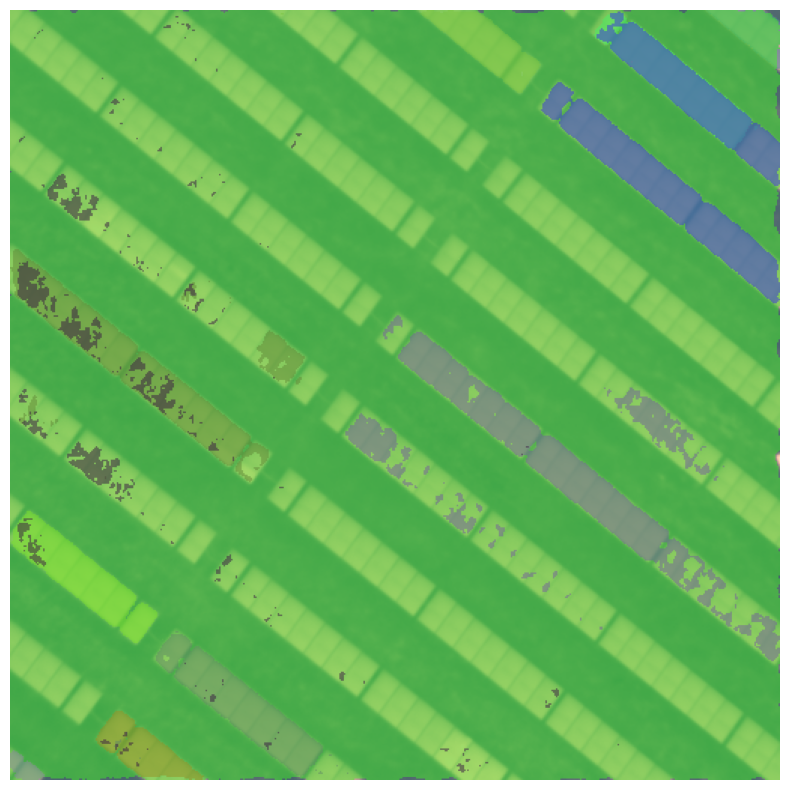

In [20]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="Parallel rows of rectangular modules or solar panels")

# Custom function to plot only masks (no bounding boxes)
def plot_masks_only(img, results):
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    nb_objects = len(results["scores"])
    print(f"found {nb_objects} object(s)")
    for i in range(nb_objects):
        color = COLORS[i % len(COLORS)]
        plot_mask(results["masks"][i].squeeze(0).cpu(), color=color)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Import the required components
from sam3.visualization_utils import COLORS, plot_mask

img0 = Image.open(image_path)
plot_masks_only(img0, inference_state)

found 149 object(s)


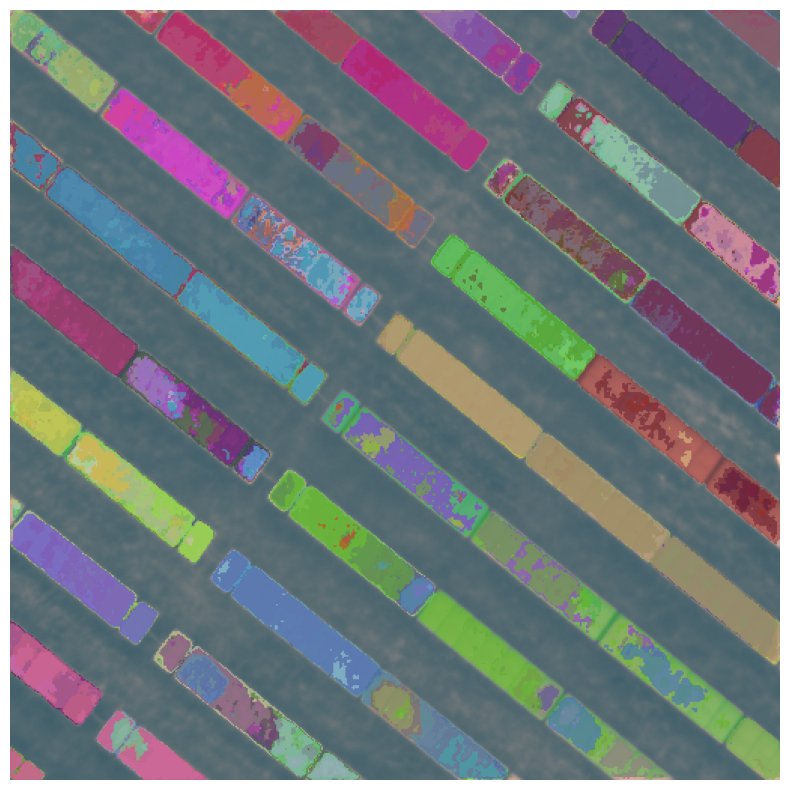

In [19]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="Parallel rows of rectangular modules")

# Custom function to plot only masks (no bounding boxes)
def plot_masks_only(img, results):
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    nb_objects = len(results["scores"])
    print(f"found {nb_objects} object(s)")
    for i in range(nb_objects):
        color = COLORS[i % len(COLORS)]
        plot_mask(results["masks"][i].squeeze(0).cpu(), color=color)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Import the required components
from sam3.visualization_utils import COLORS, plot_mask

img0 = Image.open(image_path)
plot_masks_only(img0, inference_state)

found 83 object(s)


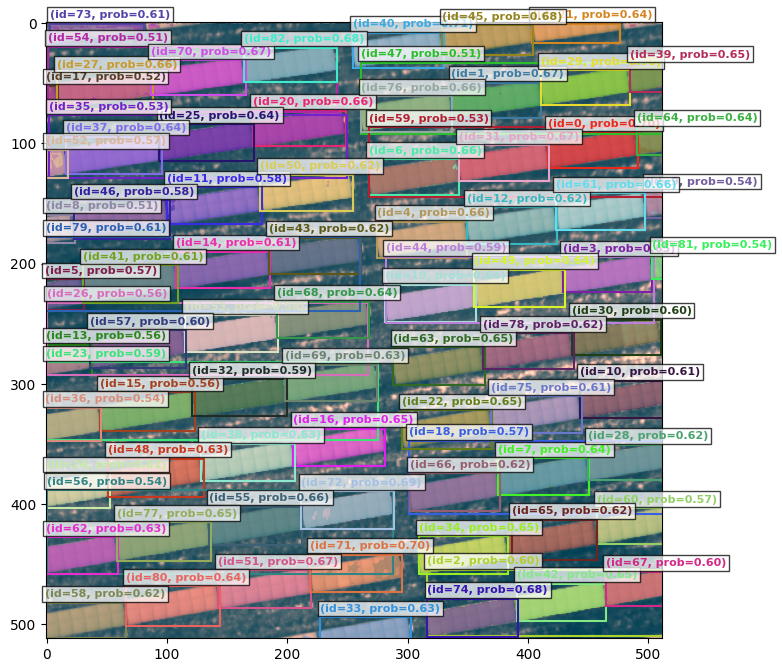

In [32]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 0 object(s)


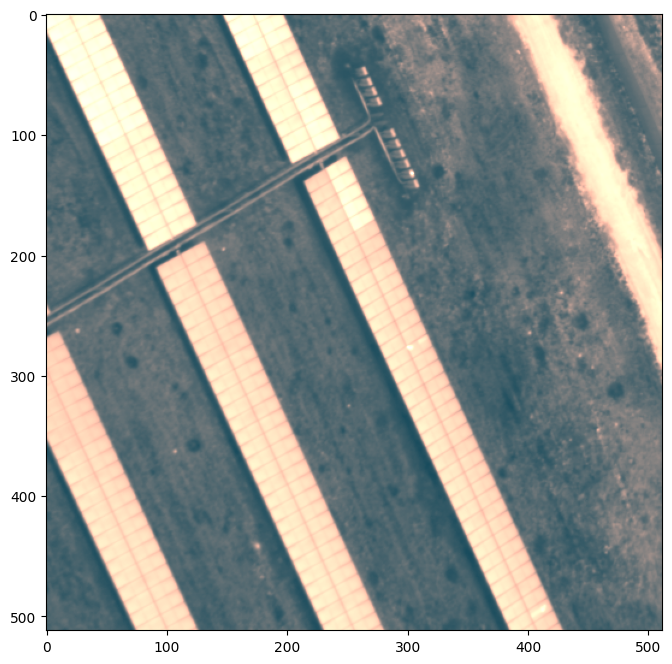

In [30]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 0 object(s)


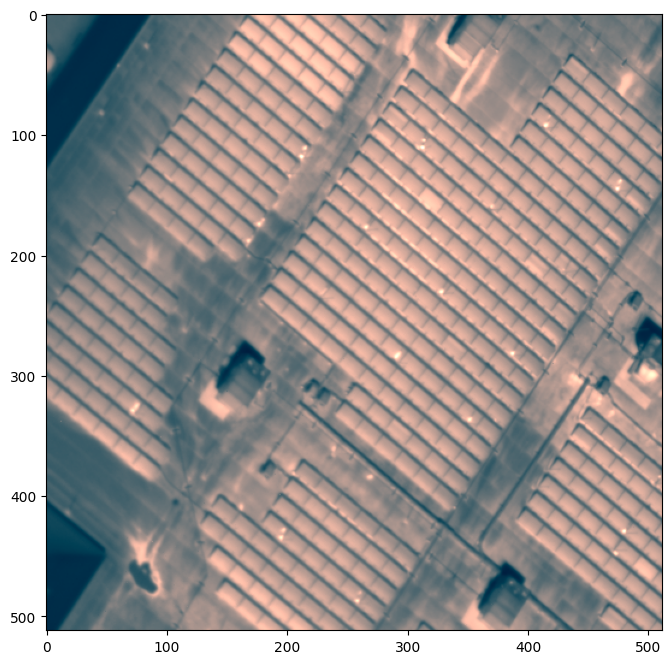

In [28]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 0 object(s)


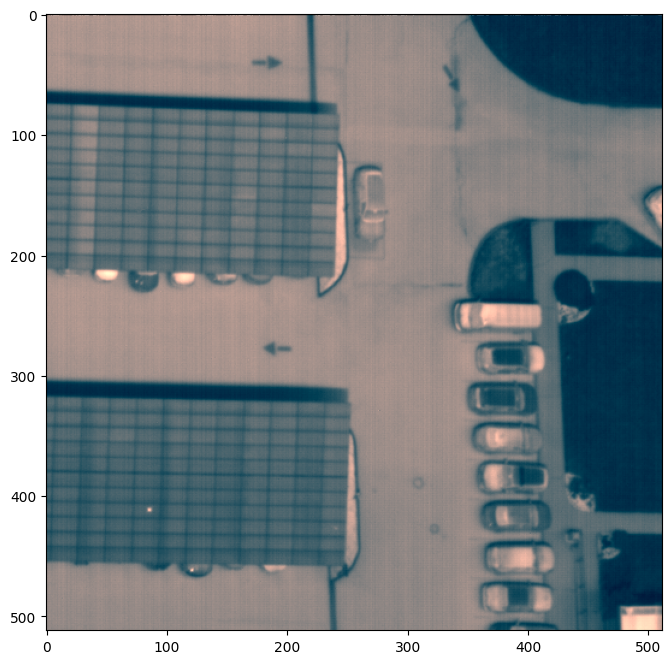

In [26]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 0 object(s)


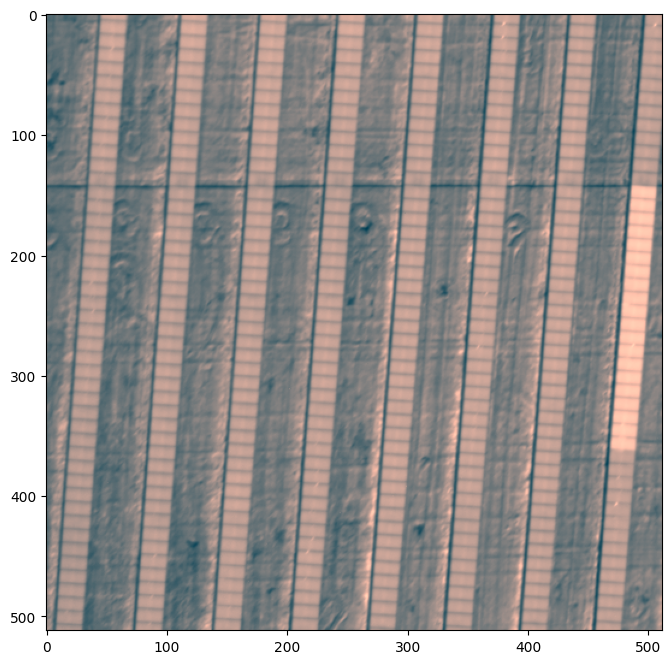

In [24]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 17 object(s)


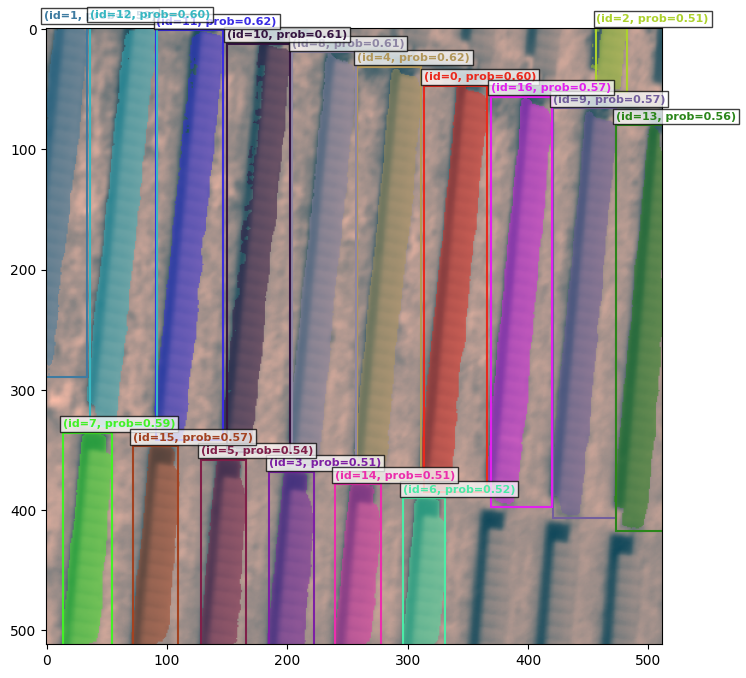

In [22]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 2 object(s)


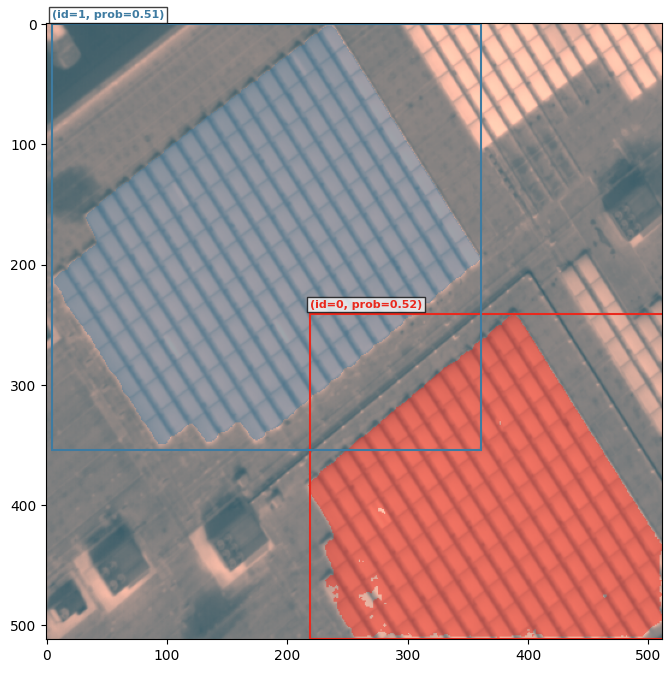

In [20]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 17 object(s)


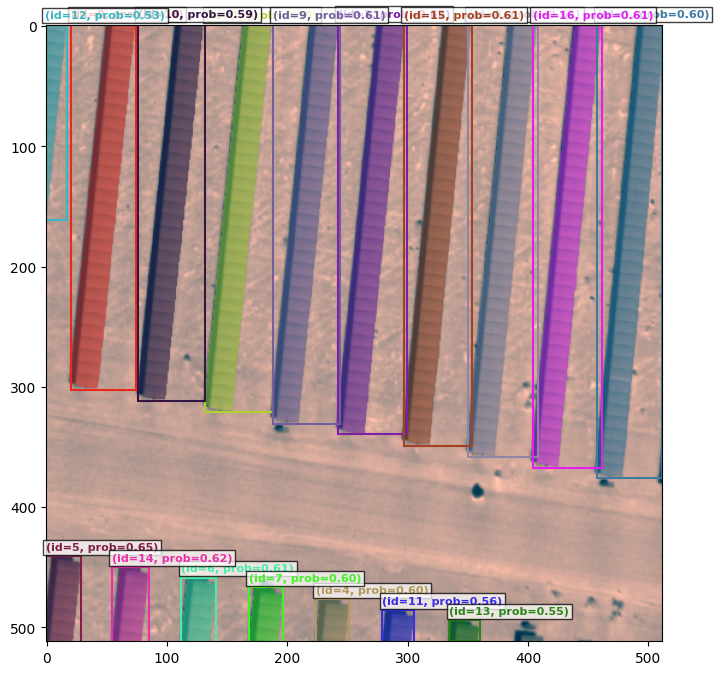

In [18]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 0 object(s)


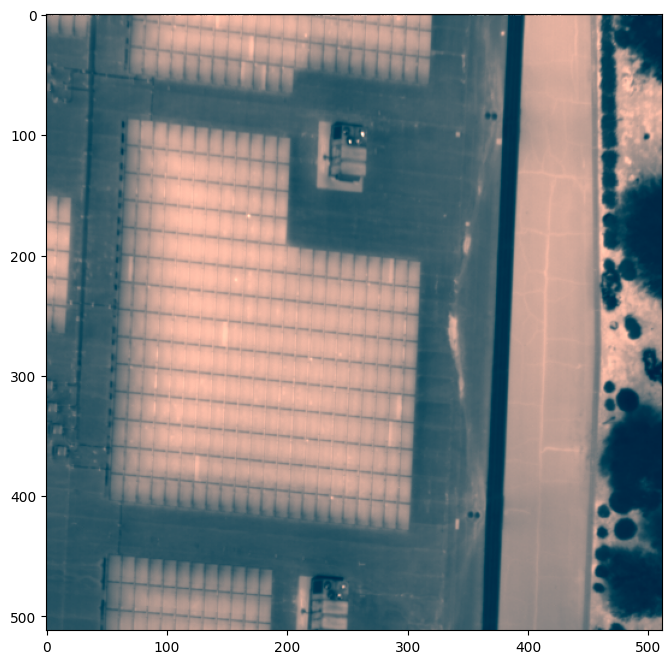

In [ ]:
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")
inference_state = processor.set_text_prompt(state=inference_state, prompt="solar panels")

img0 = Image.open(image_path)
plot_results(img0, inference_state)